In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from glob import glob
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
from scipy import stats

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [43]:
# Reading the CSV file
skin_df = pd.read_csv('HAM10000_metadata.csv')

In [45]:
print(skin_df.head())

print(skin_df.tail())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
         lesion_id      image_id     dx dx_type   age     sex localization
10010  HAM_0002867  ISIC_0033084  akiec   histo  40.0    male      abdomen
10011  HAM_0002867  ISIC_0033550  akiec   histo  40.0    male      abdomen
10012  HAM_0002867  ISIC_0033536  akiec   histo  40.0    male      abdomen
10013  HAM_0000239  ISIC_0032854  akiec   histo  80.0    male         face
10014  HAM_0003521  ISIC_0032258    mel   histo  70.0  female         back


In [47]:
print("\nDisease types:", skin_df['dx'].unique())  # Listing the unique disease classes = 7


Disease types: ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


In [49]:
# Label encoding to convert text labels to numbers
le = LabelEncoder()
skin_df['label'] = le.fit_transform(skin_df['dx'])

# To show the mapping
print("Class labels:")
for i, name in enumerate(le.classes_):
    print("{} -> {}".format(i,name))

Class labels:
0 -> akiec
1 -> bcc
2 -> bkl
3 -> df
4 -> mel
5 -> nv
6 -> vasc


In [51]:
print(skin_df.sample(10))

        lesion_id      image_id     dx    dx_type   age     sex  \
9641  HAM_0006861  ISIC_0031216     nv  consensus  50.0  female   
5755  HAM_0004335  ISIC_0025187     nv  follow_up  60.0  female   
3100  HAM_0002151  ISIC_0029870     nv  follow_up  65.0    male   
9169  HAM_0004095  ISIC_0026017     nv      histo  65.0    male   
2673  HAM_0007550  ISIC_0026528    bcc      histo  70.0    male   
9688  HAM_0006002  ISIC_0029915  akiec      histo  50.0  female   
9632  HAM_0007069  ISIC_0029355     nv  consensus  50.0  female   
5381  HAM_0002718  ISIC_0024316     nv  follow_up  55.0    male   
6295  HAM_0000307  ISIC_0027011     nv  follow_up  65.0    male   
9671  HAM_0003965  ISIC_0025652     nv  consensus  15.0  female   

         localization  label  
9641             back      5  
5755             back      5  
3100          abdomen      5  
9169             back      5  
2673            trunk      1  
9688             face      0  
9632  lower extremity      5  
5381          

In [53]:
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2


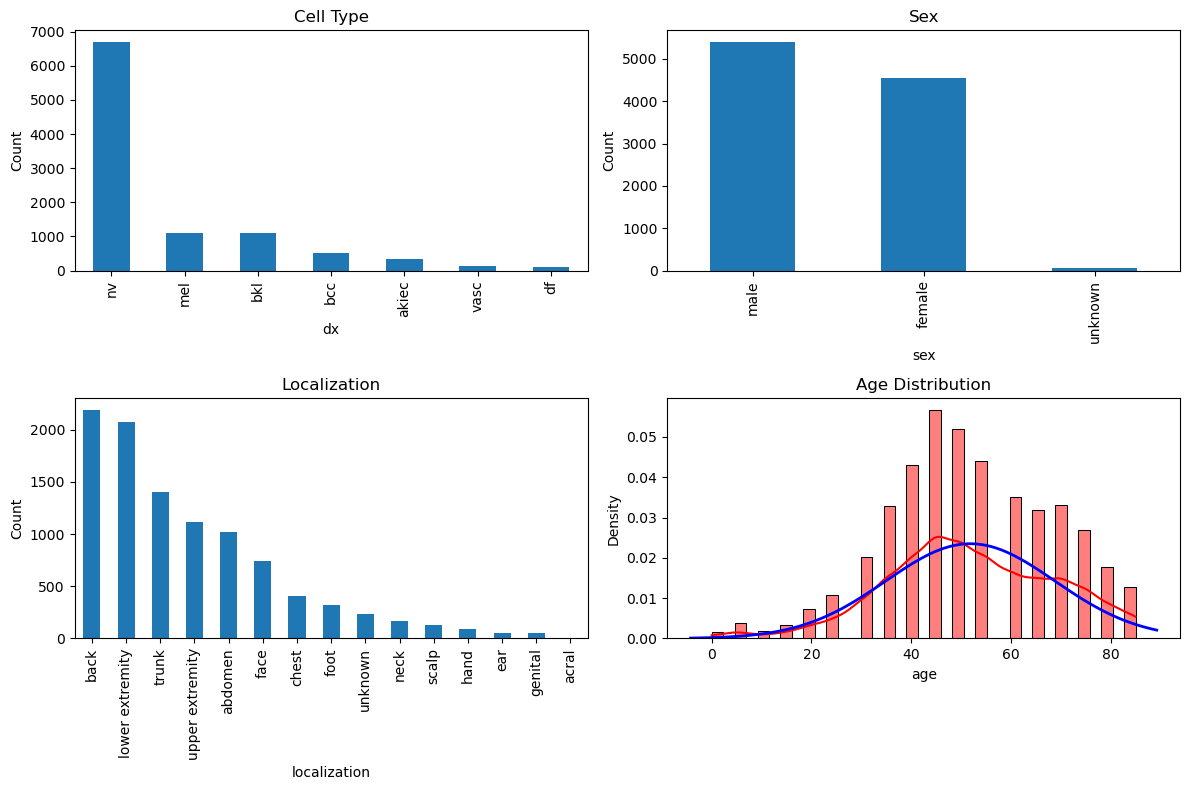

In [55]:
# Data distribution visualization
fig = plt.figure(figsize=(12, 8))

# ----------- Plot 1: Cell Type -----------
ax1 = fig.add_subplot(221)
skin_df['dx'].value_counts().plot(kind='bar', ax=ax1)
ax1.set_ylabel('Count')
ax1.set_title('Cell Type')

# ----------- Plot 2: Sex -----------
ax2 = fig.add_subplot(222)
skin_df['sex'].value_counts().plot(kind='bar', ax=ax2)
ax2.set_ylabel('Count')
ax2.set_title('Sex')

# ----------- Plot 3: Localization -----------
ax3 = fig.add_subplot(223)
skin_df['localization'].value_counts().plot(kind='bar', ax=ax3)
ax3.set_ylabel('Count')
ax3.set_title('Localization')

# ----------- Plot 4: Age Distribution (Updated distplot) -----------
ax4 = fig.add_subplot(224)

#sample_age = skin_df[pd.notnull(skin_df['age'])]
age_data = skin_df['age'].dropna()

# Histogram + KDE
sns.histplot(age_data, kde=True, stat='density', color='red', ax=ax4)

# Fitted normal curve
mean, std_dev = stats.norm.fit(age_data)
xmin, xmax = ax4.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean, std_dev)

ax4.plot(x, p, linewidth=2, color = 'blue')      # normal curve
ax4.set_title('Age Distribution')
ax4.set_xlabel('age')
ax4.set_ylabel('Density')

plt.tight_layout()
plt.show()


In [57]:
# Distribution of data into various classes 
from sklearn.utils import resample
print(skin_df['label'].value_counts())

label
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


**From the graph and the value, we can infer that the data is imbalanced.**

In [59]:
# Reading all image paths (all .jpg files in both image folders)
image_path = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join('HAM10000_images_part_*', '*.jpg'))
}

# Adding a new column 'path' to the table
skin_df['path'] = skin_df['image_id'].map(image_path.get)

# Droping any rows where image was not found
skin_df = skin_df.dropna(subset=['path'])

print(f"Total images available: {len(skin_df)}")

Total images available: 10015


In [61]:
# Showing the number of images for each disease
print("\nImages per class:")
print(skin_df['dx'].value_counts())


Images per class:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


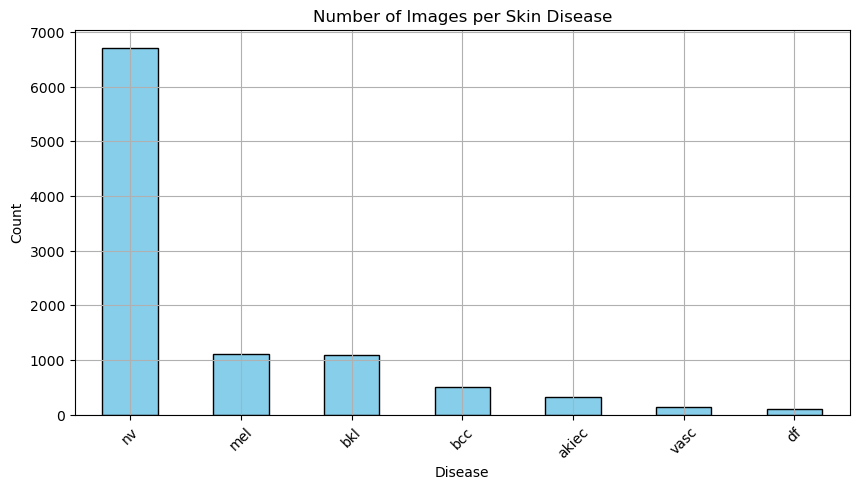

In [63]:
# Ploting bar chart
plt.figure(figsize=(10, 5))
skin_df['dx'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Number of Images per Skin Disease")
plt.ylabel("Count")
plt.xlabel("Disease")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [65]:
SIZE = 64  # 64x64 pixels 

# To read all images and resize them
skin_df['image'] = skin_df['path'].map(
    lambda x: np.asarray(Image.open(x).resize((SIZE, SIZE)))
)

# Converting images into a big array: X
X = np.asarray(skin_df['image'].tolist())
X = X / 255.0  # scale from 0–255 to 0–1 i.e., normalisation

# Converting disease labels into one‑hot vectors (for 7 classes)
Y = skin_df['label']
Y_cat = to_categorical(Y, num_classes=7)

print("X shape (images):", X.shape)
print("Y_cat shape (labels):", Y_cat.shape)

X shape (images): (10015, 64, 64, 3)
Y_cat shape (labels): (10015, 7)


In [69]:
# Spliting the data into 85% for train and validation and 15% for test
X_trainval, X_test, Y_trainval, Y_test, y_trainval_labels, y_test_labels = train_test_split(
    X, Y_cat, Y, test_size=0.15, random_state=42, stratify=Y
)

X_train, X_val, Y_train, Y_val, y_train_labels, y_val_labels = train_test_split(
    X_trainval, Y_trainval, y_trainval_labels, test_size=0.1765, random_state=42, stratify=y_trainval_labels
)

In [71]:
print("Training samples:", x_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples:", x_test.shape[0])

Training samples: 7511
Validation samples: 1503
Testing samples: 2504


In [82]:
# Computing class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:", class_weight_dict)

Class weights: {0: 4.372426699937617, 1: 2.7813492063492062, 2: 1.3020620471855842, 3: 12.51607142857143, 4: 1.2853475151292866, 5: 0.2133572798392743, 6: 10.113997113997113}


## Data Augmentation

In [85]:
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(
    X_train, Y_train,
    batch_size=32,
    shuffle=True
)

val_generator = val_test_datagen.flow(
    X_val, Y_val,
    batch_size=32,
    shuffle=False
)

test_generator = val_test_datagen.flow(
    X_test, Y_test,
    batch_size=32,
    shuffle=False
)

In [87]:
BATCH_SIZE = 32
EPOCHS = 30

# Callbacks: To reduce the learning rate if the model gets stuck; also stops early if no improvement
callbacks = [
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True)
]

## Training with 3 Convolution Models

In [89]:
model = Sequential()

# Input layer: each image is 64x64x3 (RGB)
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(SIZE, SIZE, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(7, activation='softmax'))  # 7 diseases

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

C:\Users\sampa\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 62, 62, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 29, 29, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,307,847 (4.99 MB)

 Trainable params: 1,307,399 (4.99 MB)

 Non-trainable params: 448 (1.75 KB)

In [91]:
history_3 = model.fit(
    X_train, Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 68s 272ms/step - accuracy: 0.3324 - loss: 3.2898 - val_accuracy: 0.0512 - val_loss: 3.9296 - learning_rate: 0.0010
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 60s 273ms/step - accuracy: 0.3584 - loss: 2.1423 - val_accuracy: 0.1091 - val_loss: 2.1874 - learning_rate: 0.0010
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 63s 286ms/step - accuracy: 0.3525 - loss: 1.8068 - val_accuracy: 0.1524 - val_loss: 2.8684 - learning_rate: 0.0010
Epoch 4/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 66s 301ms/step - accuracy: 0.3672 - loss: 1.7889 - val_accuracy: 0.4212 - val_loss: 1.4360 - learning_rate: 0.0010
Epoch 5/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 69s 310ms/step - accuracy: 0.4319 - loss: 1.5876 - val_accuracy: 0.1870 - val_loss: 1.8653 - learning_rate: 0.0010
Epoch 6/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 78s 355ms/step - accuracy: 0.4058 - loss: 1.5545 - val_accuracy: 0.3699 - val_loss: 1.5714 - learning_rate: 0.0010
Epoch 7/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 83s 375ms/step - accuracy: 0.4

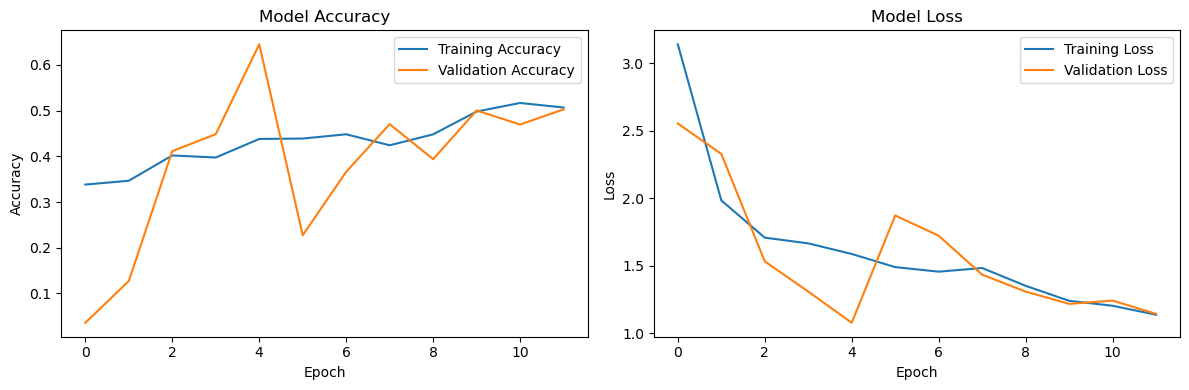

In [93]:
# Accuracy plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Test Loss: 1.3679615259170532
Test Accuracy: 0.6565495133399963
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step


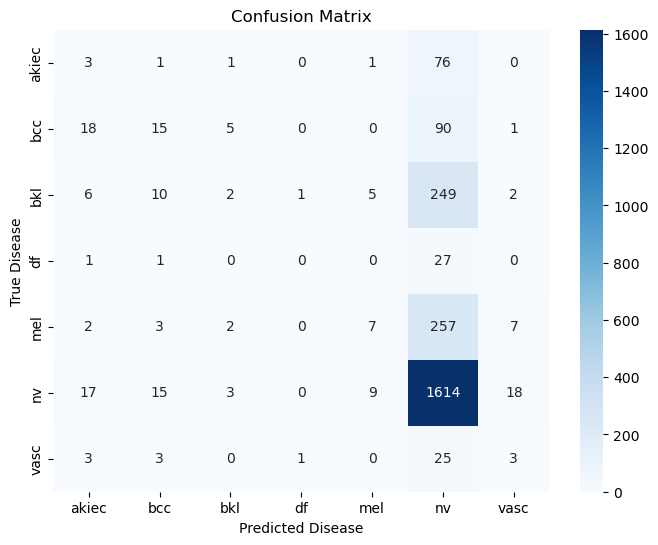


Classification Report:
              precision    recall  f1-score   support

       akiec       0.06      0.04      0.05        82
         bcc       0.31      0.12      0.17       129
         bkl       0.15      0.01      0.01       275
          df       0.00      0.00      0.00        29
         mel       0.32      0.03      0.05       278
          nv       0.69      0.96      0.80      1676
        vasc       0.10      0.09      0.09        35

    accuracy                           0.66      2504
   macro avg       0.23      0.18      0.17      2504
weighted avg       0.53      0.66      0.56      2504



In [95]:
# Test accuracy
score = model.evaluate(x_test, y_test, verbose=0)
print("Test Loss:", score[0])
print("Test Accuracy:", score[1])

# Predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("True Disease")
plt.show()

# Detailed report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

In [97]:
results = []  ## This will store the result of the 3 experimental CNNs

In [99]:
score_3 = model.evaluate(X_test, Y_test, verbose=0)
print("Test Loss (3 conv):", score_3[0])
print("Test Accuracy (3 conv):", score_3[1])

results.append({
    "depth": 3,
    "model": model,
    "history": history_3,
    "test_acc": score_3[1],
    "best_val_acc": max(history_3.history['val_accuracy'])
})

Test Loss (3 conv): 1.3481148481369019
Test Accuracy (3 conv): 0.658682644367218


## Training with 4 convolutional layers

In [101]:
model_4 = Sequential(name="CNN_4_Conv")
model_4.add(Conv2D(32, (3, 3), activation='relu', input_shape=(SIZE, SIZE, 3)))
model_4.add(BatchNormalization())
model_4.add(MaxPooling2D((2, 2)))

model_4.add(Conv2D(64, (3, 3), activation='relu'))
model_4.add(BatchNormalization())
model_4.add(MaxPooling2D((2, 2)))

model_4.add(Conv2D(128, (3, 3), activation='relu'))
model_4.add(BatchNormalization())
model_4.add(MaxPooling2D((2, 2)))

model_4.add(Conv2D(256, (3, 3), activation='relu'))
model_4.add(BatchNormalization())
model_4.add(MaxPooling2D((2, 2)))

model_4.add(Flatten())
model_4.add(Dense(256, activation='relu'))
model_4.add(Dropout(0.5))
model_4.add(Dense(128, activation='relu'))
model_4.add(Dropout(0.3))
model_4.add(Dense(7, activation='softmax'))

model_4.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_4.summary()

C:\Users\sampa\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_4_Conv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 62, 62, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 29, 29, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 4, 4, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 4, 4, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 686,535 (2.62 MB)

 Trainable params: 685,575 (2.62 MB)

 Non-trainable params: 960 (3.75 KB)

In [103]:
history_4 = model_4.fit(
    X_train, Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 111s 482ms/step - accuracy: 0.3560 - loss: 2.2413 - val_accuracy: 0.1151 - val_loss: 2.4075 - learning_rate: 0.0010
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 120s 381ms/step - accuracy: 0.4227 - loss: 1.7577 - val_accuracy: 0.0705 - val_loss: 2.2244 - learning_rate: 0.0010
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.4031 - loss: 1.7104
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
220/220 ━━━━━━━━━━━━━━━━━━━━ 78s 356ms/step - accuracy: 0.4055 - loss: 1.6873 - val_accuracy: 0.2096 - val_loss: 1.7116 - learning_rate: 0.0010
Epoch 4/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 84s 383ms/step - accuracy: 0.4601 - loss: 1.4822 - val_accuracy: 0.4471 - val_loss: 1.3999 - learning_rate: 5.0000e-04
Epoch 5/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 74s 336ms/step - accuracy: 0.4778 - loss: 1.3540 - val_accuracy: 0.5303 - val_loss: 1.0938 - learning_rate: 5.0000e-04
Epoch 6/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accura

In [105]:
score_4 = model_4.evaluate(X_test, Y_test, verbose=0)
print("Test Loss (4 conv):", score_4[0])
print("Test Accuracy (4 conv):", score_4[1])

results.append({
    "depth": 4,
    "model": model_4,
    "history": history_4,
    "test_acc": score_4[1],
    "best_val_acc": max(history_4.history['val_accuracy'])
})

Test Loss (4 conv): 2.4072532653808594
Test Accuracy (4 conv): 0.12175648659467697


## Training with 5 convolutional layers

In [107]:
model_5 = Sequential(name="CNN_5_Conv")
model_5.add(Conv2D(32, (3, 3), activation='relu', input_shape=(SIZE, SIZE, 3)))
model_5.add(BatchNormalization())
model_5.add(MaxPooling2D((2, 2)))

model_5.add(Conv2D(64, (3, 3), activation='relu'))
model_5.add(BatchNormalization())
model_5.add(MaxPooling2D((2, 2)))

model_5.add(Conv2D(128, (3, 3), activation='relu'))
model_5.add(BatchNormalization())
model_5.add(MaxPooling2D((2, 2)))

model_5.add(Conv2D(256, (3, 3), activation='relu'))
model_5.add(BatchNormalization())
model_5.add(MaxPooling2D((2, 2)))

model_5.add(Conv2D(256, (3, 3), activation='relu'))
model_5.add(BatchNormalization())
model_5.add(MaxPooling2D((2, 2)))

model_5.add(Flatten())
model_5.add(Dense(256, activation='relu'))
model_5.add(Dropout(0.5))
model_5.add(Dense(128, activation='relu'))
model_5.add(Dropout(0.3))
model_5.add(Dense(7, activation='softmax'))

model_5.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_5.summary()

C:\Users\sampa\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_5_Conv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)                   │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 62, 62, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 29, 29, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 4, 4, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 4, 4, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 0, 0, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 0, 0, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 0, 0, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 0)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 256)                 │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 128)                 │          32,8

 Total params: 1,015,495 (3.87 MB)

 Trainable params: 1,014,023 (3.87 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [109]:
history_5 = model_5.fit(
    X_train, Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


ValueError: Exception encountered when calling Conv2D.call().

[1mNegative dimension size caused by subtracting 3 from 2 for '{{node CNN_5_Conv_1/conv2d_17_1/convolution}} = Conv2D[T=DT_FLOAT, data_format="NHWC", dilations=[1, 1, 1, 1], explicit_paddings=[], padding="VALID", strides=[1, 1, 1, 1], use_cudnn_on_gpu=true](CNN_5_Conv_1/max_pooling2d_16_1/MaxPool2d, CNN_5_Conv_1/conv2d_17_1/convolution/ReadVariableOp)' with input shapes: [?,2,2,256], [3,3,256,256].[0m

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(None, 2, 2, 256), dtype=float32)

In [111]:
results_df = pd.DataFrame([{
    "conv_blocks": r["depth"],
    "best_val_accuracy": r["best_val_acc"],
    "test_accuracy": r["test_acc"]
} for r in results])

In [113]:
results_df

,conv_blocks,best_val_accuracy,test_accuracy
0,3,0.654691,0.658683
1,4,0.530273,0.121756
